In [15]:
import pandas as pd
import matplotlib.pyplot as plt

## 데이터 불러오기

In [16]:
# 데이터 로드
file_path = "./processed_data.xlsx"
df = pd.read_excel(file_path)

d:\env\envs\aimers\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\env\envs\aimers\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\env\envs\aimers\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\env\envs\aimers\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


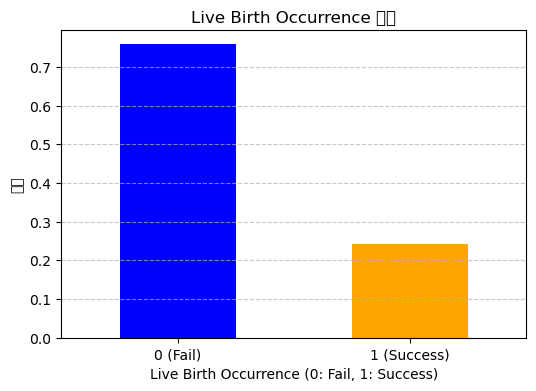

In [17]:
# Live Birth Occurrence 분포 확인
live_birth_counts = df["Live birth occurrence"].value_counts(normalize=True)

# 히스토그램 시각화
plt.figure(figsize=(6, 4))
live_birth_counts.plot(kind="bar", color=["blue", "orange"])
plt.xlabel("Live Birth Occurrence (0: Fail, 1: Success)")
plt.ylabel("비율")
plt.title("Live Birth Occurrence 분포")
plt.xticks([0, 1], ["0 (Fail)", "1 (Success)"], rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

In [18]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
import numpy as np

# 독립 변수(X)와 타겟 변수(y) 분리
X = df.drop(columns=["Live birth occurrence"])
X = X.drop(columns=["Number of live births"]) # 출생아 수 특성 제외

y = df["Live birth occurrence"]

# 학습 데이터와 테스트 데이터 나누기 (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# XGBoost 모델 설정 및 학습
model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=np.sum(y == 0) / np.sum(y == 1),  # 클래스 불균형 조정
    random_state=42,
    eval_metric="auc"
)

model.fit(X_train, y_train)

# 예측 및 평가
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

accuracy, roc_auc


(0.6228333922886452, 0.7618474608113437)

In [19]:
print(X_train.corrwith(y_train).sort_values(ascending=False))


Embryos transferred                               0.225998
Elective single embryo transfer                   0.203599
Main reason for producing embroys storing eggs    0.193451
Frozen cycle                                      0.112766
Total embryos thawed                              0.109325
Specific treatment type                           0.063257
Type of treatment - IVF or DI                     0.061396
Causes of infertility - male factor               0.056664
Causes of infertility - ovulatory disorder        0.035674
Patient ethnicity                                 0.033364
PGT-A treatment                                   0.032483
Partner ethnicity                                 0.030976
Donated embryo                                    0.030383
PGT-M treatment                                   0.026596
Total embryos created                             0.026049
Causes of infertility - tubal disease             0.023574
Sperm source                                      0.0214

In [20]:
from sklearn.model_selection import GridSearchCV

# 하이퍼파라미터 그리드 정의
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'scale_pos_weight': [np.sum(y == 0) / np.sum(y == 1)]  # 불균형 데이터 처리
}

# XGBoost 모델 생성
xgb_model = XGBClassifier(random_state=42, tree_method="hist", eval_metric="auc")

# GridSearchCV 실행 (교차 검증 포함)
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=3,
    verbose=1,
    n_jobs=-1  # 병렬 처리
)

grid_search.fit(X_train, y_train)

# 최적의 하이퍼파라미터 출력
best_params = grid_search.best_params_
best_params


AttributeError: 'super' object has no attribute '__sklearn_tags__'